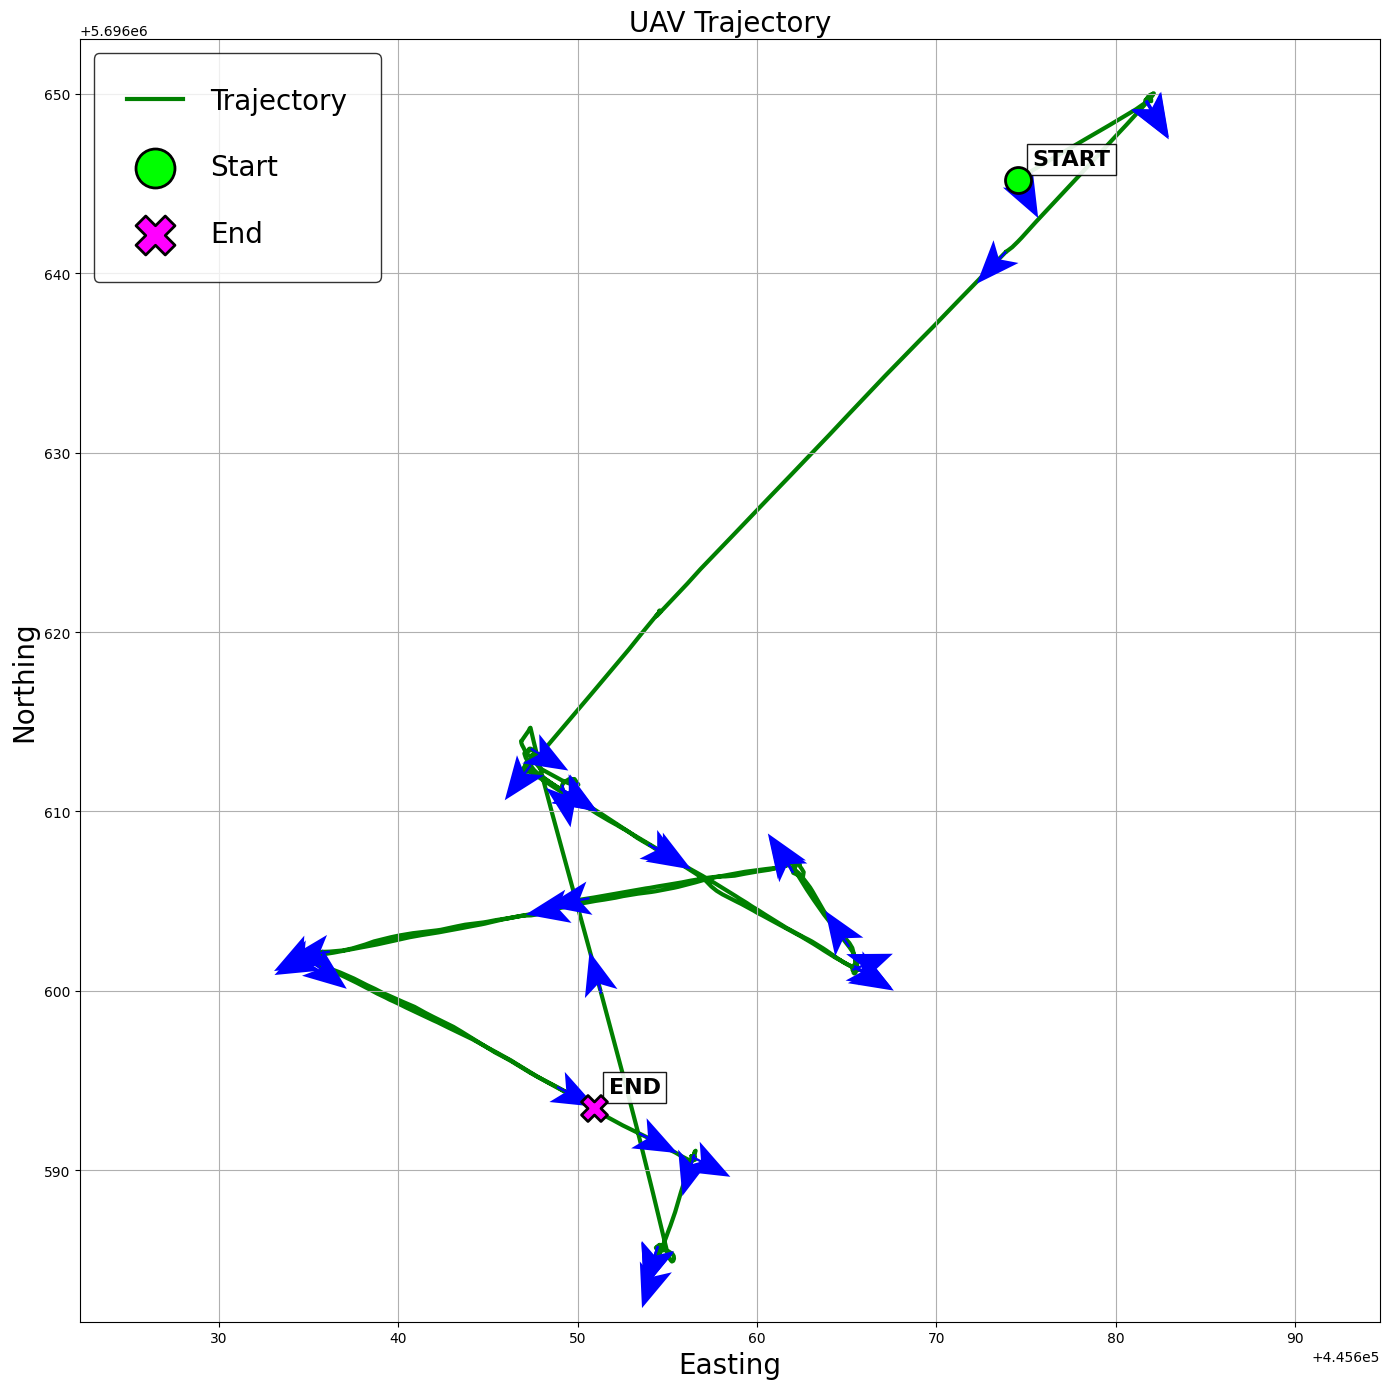

In [17]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer
import rasterio

#-------------------- PATH --------------------
DSM_PATH = "../../Maps/rgb_wide_images-only_dsm.tif"

if not os.path.exists(DSM_PATH):
    raise FileNotFoundError(f"DSM not found: {DSM_PATH}")

with rasterio.open(DSM_PATH) as src:
    dsm_band = src.read(1)
    dsm_crs = src.crs

# ---------- CONFIG ----------
meta_path  = "extracted_images2/metadata_with_euler.csv"
meta_data = pd.read_csv(meta_path)

transformer = Transformer.from_crs("EPSG:4326", dsm_crs, always_xy=True)

# ---------- TRAJECTORY ----------
all_easting, all_northing = [], []

for i in range(1, 1327):
    row = meta_data.iloc[i]
    e, n = transformer.transform(row["gps_longitude"], row["gps_latitude"])
    all_easting.append(e)
    all_northing.append(n)

all_easting = np.array(all_easting)
all_northing = np.array(all_northing)

traj_size = np.sqrt((all_easting.max() - all_easting.min())**2 +
                    (all_northing.max() - all_northing.min())**2)

arrow_length = traj_size * 0.03

# Offset for labels 
offset = traj_size * 0.01

# ---------- PLOT ----------
plt.figure(figsize=(14,14))

# Trajectory
plt.plot(all_easting, all_northing,
         color='green', linewidth=3, label="Trajectory", zorder=1)

# Start / End markers 
plt.scatter(all_easting[0], all_northing[0],
            color='lime', s=350, edgecolors='black', linewidth=2,
            label='Start', zorder=5)

plt.scatter(all_easting[-1], all_northing[-1],
            color='magenta', s=350, marker='X', edgecolors='black', linewidth=2,
            label='End', zorder=5)

# ---------- LABEL POSITIONS ----------
plt.text(all_easting[0] + offset, all_northing[0] + offset,
         "START",
         fontsize=16, weight='bold',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'),
         zorder=4)

plt.text(all_easting[-1] + offset, all_northing[-1] + offset,
         "END",
         fontsize=16, weight='bold',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='black'),
         zorder=4)

# ---------- ARROWS ----------
skip = 40

for i in range(1, 1327):
    if i % skip != 0:
        continue

    row = meta_data.iloc[i]

    e, n = transformer.transform(row["gps_longitude"], row["gps_latitude"])
    yaw = float(row["yaw"])

    dx = arrow_length * np.cos(yaw)
    dy = arrow_length * np.sin(yaw)

    plt.quiver(e, n, dx, dy,
               angles='xy', scale_units='xy', scale=1,
               color='blue',
               width=0.004,
               headwidth=14,
               headlength=18,
               headaxislength=14,
               zorder=2)

# ---------- FINAL ----------
plt.xlabel("Easting", fontsize=20)
plt.ylabel("Northing", fontsize=20)
plt.title("UAV Trajectory", fontsize=20)

plt.axis('equal')
plt.grid(True)

# ---------- LEGEND ----------
plt.legend(
    loc='upper left',
    fontsize=20,
    markerscale=1.5,
    frameon=True,
    facecolor='white',
    edgecolor='black',
    labelspacing=1.4,
    handletextpad=1.0,
    borderpad=1.2
)

plt.tight_layout()
plt.savefig('trajectory.png', dpi=300)
plt.show()